# インド株 ファクター検証 — Step 4: ファクターリターン（クロスセクション回帰）

各時点 $t$ で、翌月リターンをファクター1本に回帰する（Fama-MacBeth 型の第1段階）:

$$r_{i,\,t \to t+1} = a_t + f_t\, x_{i,t} + u_{i,t}, \qquad i \in \mathcal{U}_t$$

- 傾き $f_t$ が**ファクターリターン**。スコア $x$ を標準化してあるので
  「**エクスポージャー1標準偏差あたりの月次リターン**」と読める
- $f_t$ は「$x$ に単位エクスポージャーを持ち、それ以外に賭けないゼロ投資ポートフォリオ」の
  リターンでもある（factor-mimicking portfolio）
- 蓄積 $\sum_{s \le t} f_s$ が右肩上がりなら、そのファクターは一貫してリターンを生んでいる

## 分位分析・IC との関係

- **分位分析**は分位内を等ウェイト（or 時価総額ウェイト）で束ねるので、
  スコアの**順序**しか使わない（分位内の差は捨てる）
- **IC** は相関そのもの。単位がないのでリターンの大きさは分からない
- **$f_t$** は両者の中間で、スコアの**距離**を使いつつ**リターンの単位**を持つ

実際、標準化スコア（クロスセクション標準偏差 1）に対しては

$$f_t \;\approx\; \mathrm{IC}^{\text{Pearson}}_t \times \sigma_t(r)$$

が成り立つ（ノート内で数値確認する）。IC を「月次リターン何 %」に翻訳したものが $f_t$。

## 回帰ウェイト

| `weighting` | 内容 | 対応するポートフォリオ |
|---|---|---|
| `ew` | 等ウェイト OLS | 等ウェイトのロングショート |
| `sqrt_cap` | $\sqrt{\text{Cap}}$ 加重 WLS | Barra 流。残差分散が時価総額に反比例する想定 |
| `cap` | 時価総額加重 WLS | 時価総額加重のロングショート |

分位分析の EW / CW と同じ切り分けで、大型株でも効くかが分かる。

In [1]:
%matplotlib inline
%config InlineBackend.figure_format = "retina"

import sys
from pathlib import Path

import numpy as np
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import factorlab as fl

fl.plotting.set_style()
pd.set_option("display.width", 220, "display.max_columns", 60, "display.float_format", lambda v: f"{v:,.4f}")

# ---- 設定 --------------------------------------------------------------------
FACTOR = "mom12_1"
FACTOR_LABEL = "Momentum (mom12_1)"
METHOD = "blom"
START, END = 200701, 202607
VARIANTS = ["none", "size", "sector", "size_sector"]
WEIGHTINGS = ["ew", "sqrt_cap", "cap"]
LABELS = fl.preprocess.VARIANT_LABEL
WLABELS = {"ew": "Equal-weighted OLS", "sqrt_cap": "sqrt(Cap)-weighted WLS", "cap": "Cap-weighted WLS"}

In [2]:
panel = fl.data.build_panel([FACTOR], start=START, end=END)
panel, score_cols = fl.preprocess.make_neutral_variants(panel, FACTOR, method=METHOD, variants=VARIANTS)
print(score_cols)

{'none': 'mom12_1_blom', 'size': 'mom12_1_blom_size', 'sector': 'mom12_1_blom_sector', 'size_sector': 'mom12_1_blom_size_sector'}


## 1. 基本形（等ウェイト OLS、素のスコア）

In [3]:
fr = fl.regression.factor_return(panel, score_cols["none"], weighting="ew")
fr.head()

,alpha,f,t_stat,r2,n,cum_f,cum_f_compound
yyyymm,,,,,,,
200701,-0.0844,0.0009,0.0928,0.0002,51.0000,0.0009,0.0009
200702,0.0159,0.0098,0.9340,0.0175,51.0000,0.0107,0.0107
200703,0.0709,0.0191,1.9850,0.0730,52.0000,0.0299,0.0301
200704,0.0704,0.0314,1.9607,0.0714,52.0000,0.0612,0.0624
200705,0.0168,0.0198,2.0027,0.0608,64.0000,0.0810,0.0834


In [4]:
fl.regression.factor_return_summary(fr).to_frame().T

,n_months,ann_return,ann_vol,IR,mean_monthly,t_stat_NW,hit_ratio,skew,worst_month,max_drawdown,fm_t_stat,mean_abs_t,frac_|t|>2,mean_r2,mean_n
factor_return,234.0000,0.0421,0.0863,0.4878,0.0038,2.1848,0.6026,-2.9544,-0.1999,-0.3171,2.3134,2.7750,0.5556,0.0346,362.0171


`ann_return` は $f_t$ を月次リターンとみなした幾何年率、`t_stat_NW` は Newey-West、
`fm_t_stat` は Fama-MacBeth の標準的な t 値（$\bar f / (\sigma_f/\sqrt{T})$）。
`mean_r2` は月次クロスセクション回帰の $R^2$ の平均で、
**1ファクターだけでは数 % しか説明できない**のが普通（残りは銘柄固有）。

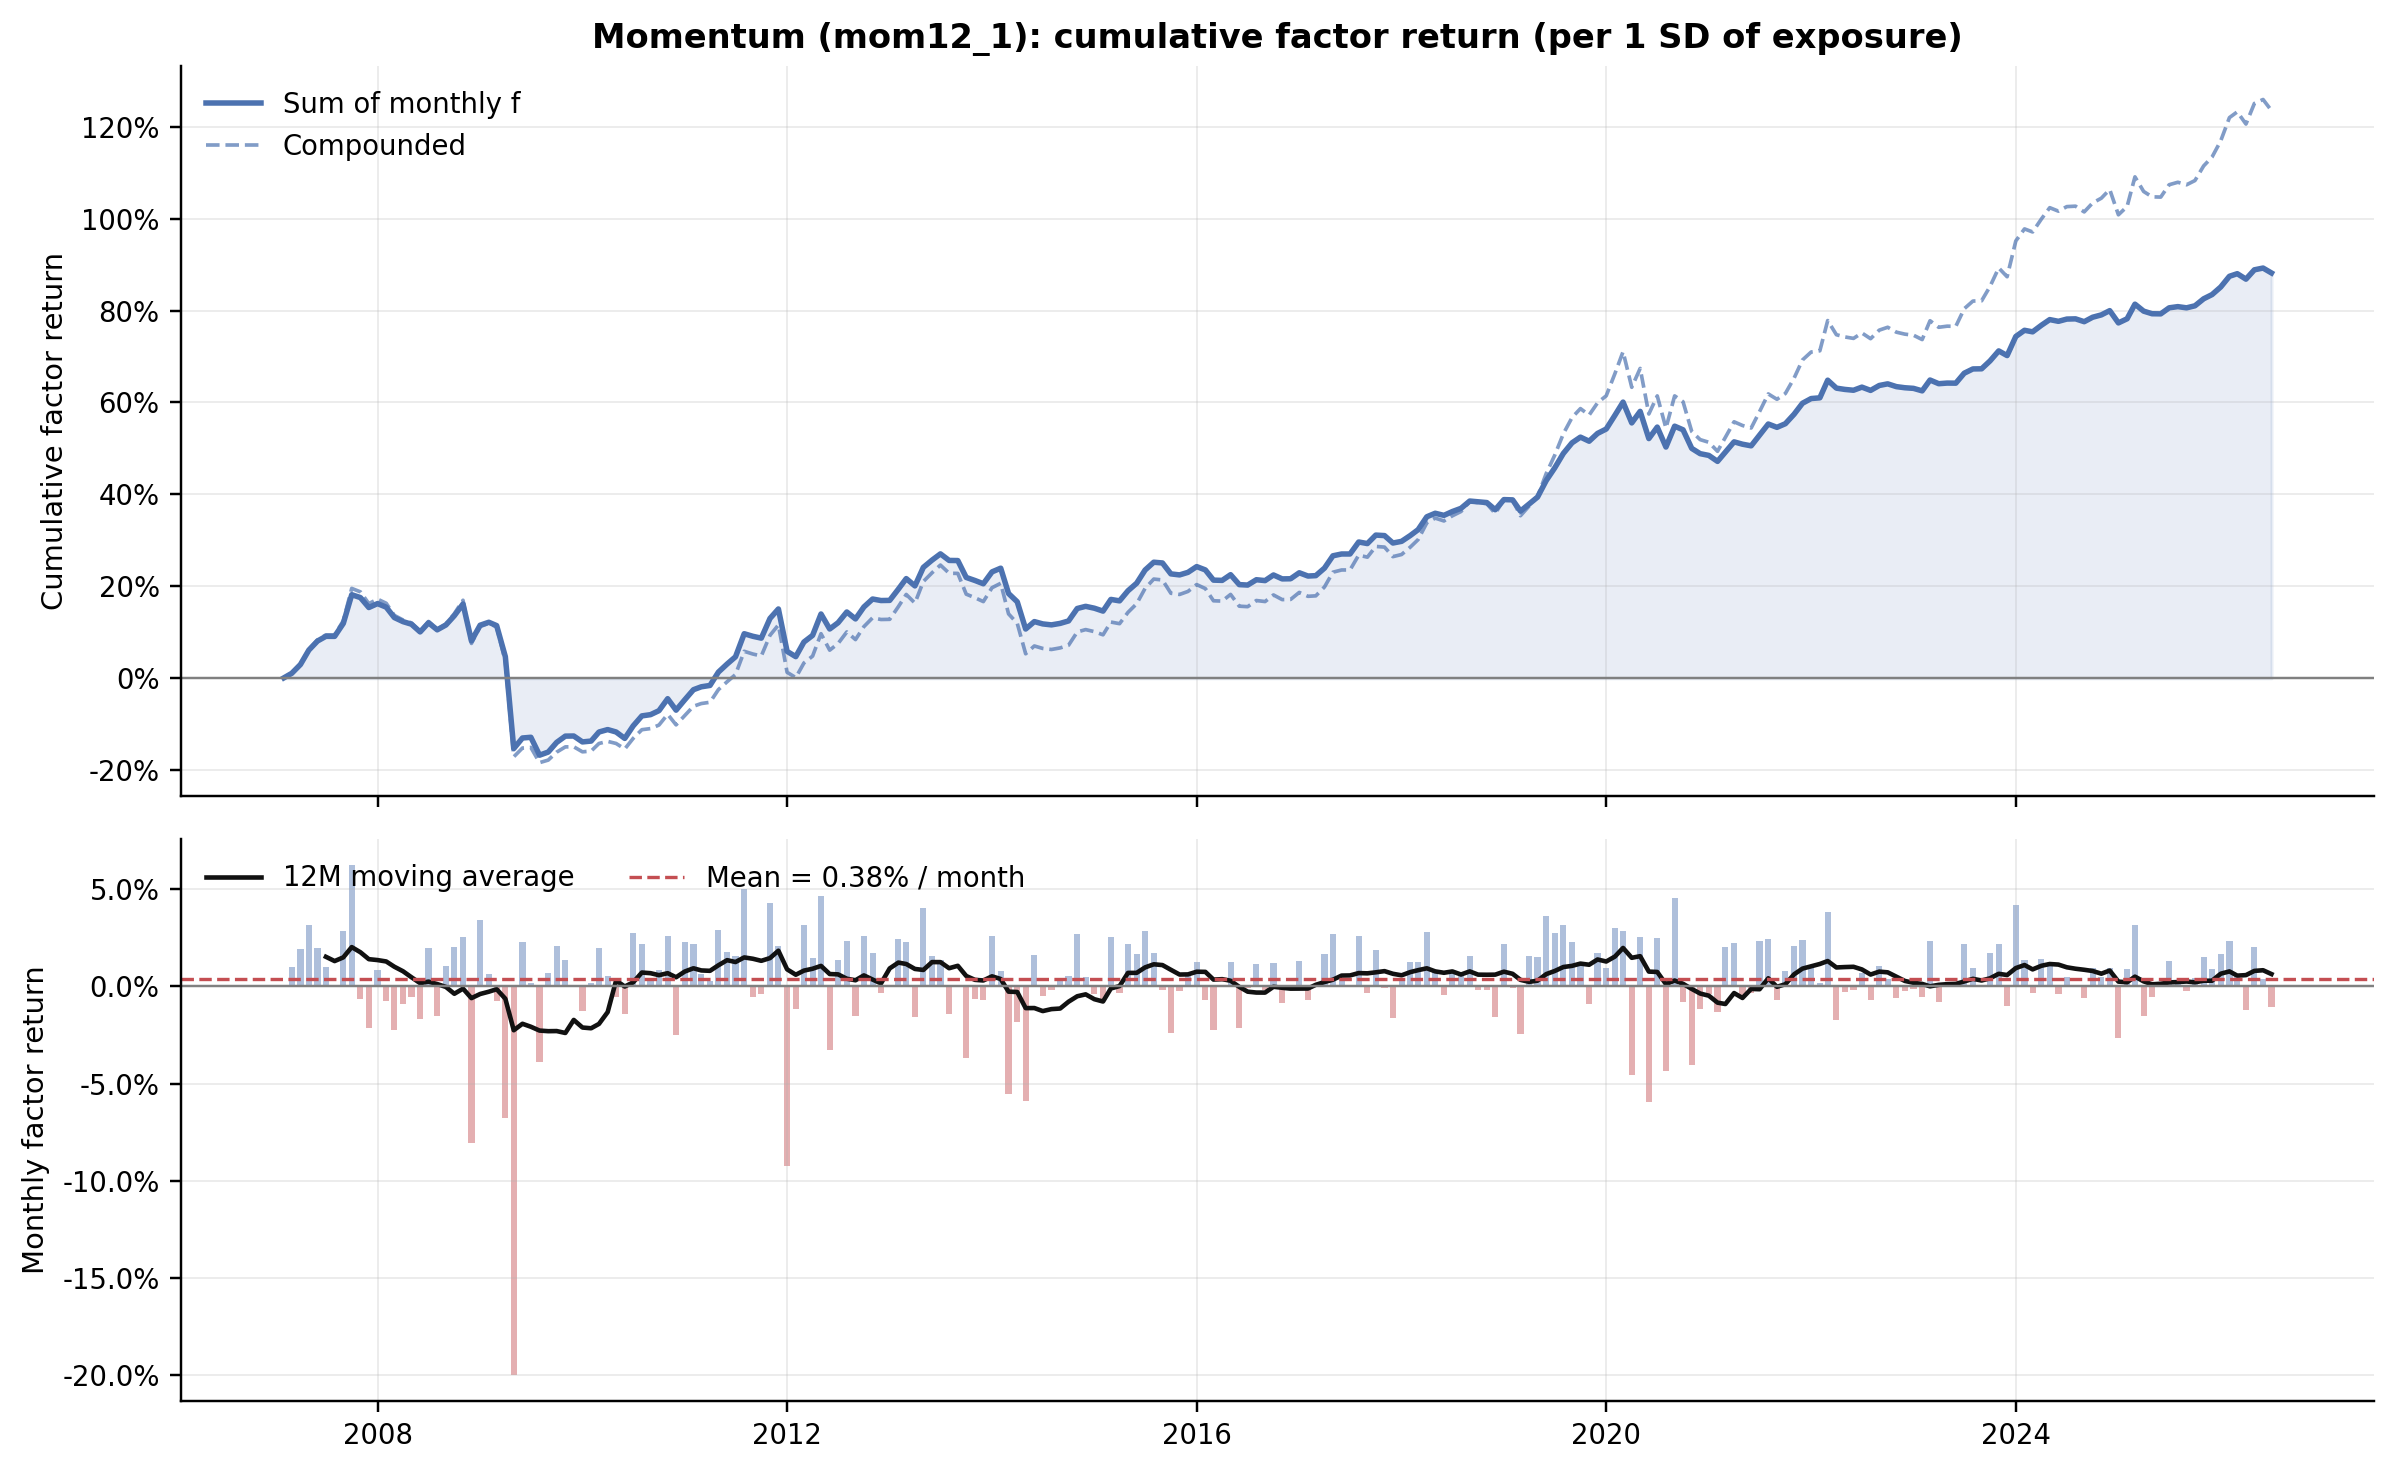

In [5]:
fig = fl.plotting.plot_factor_return(fr, factor=FACTOR_LABEL)
fl.plotting.savefig(fig, "04_factor_return/30_factor_return");

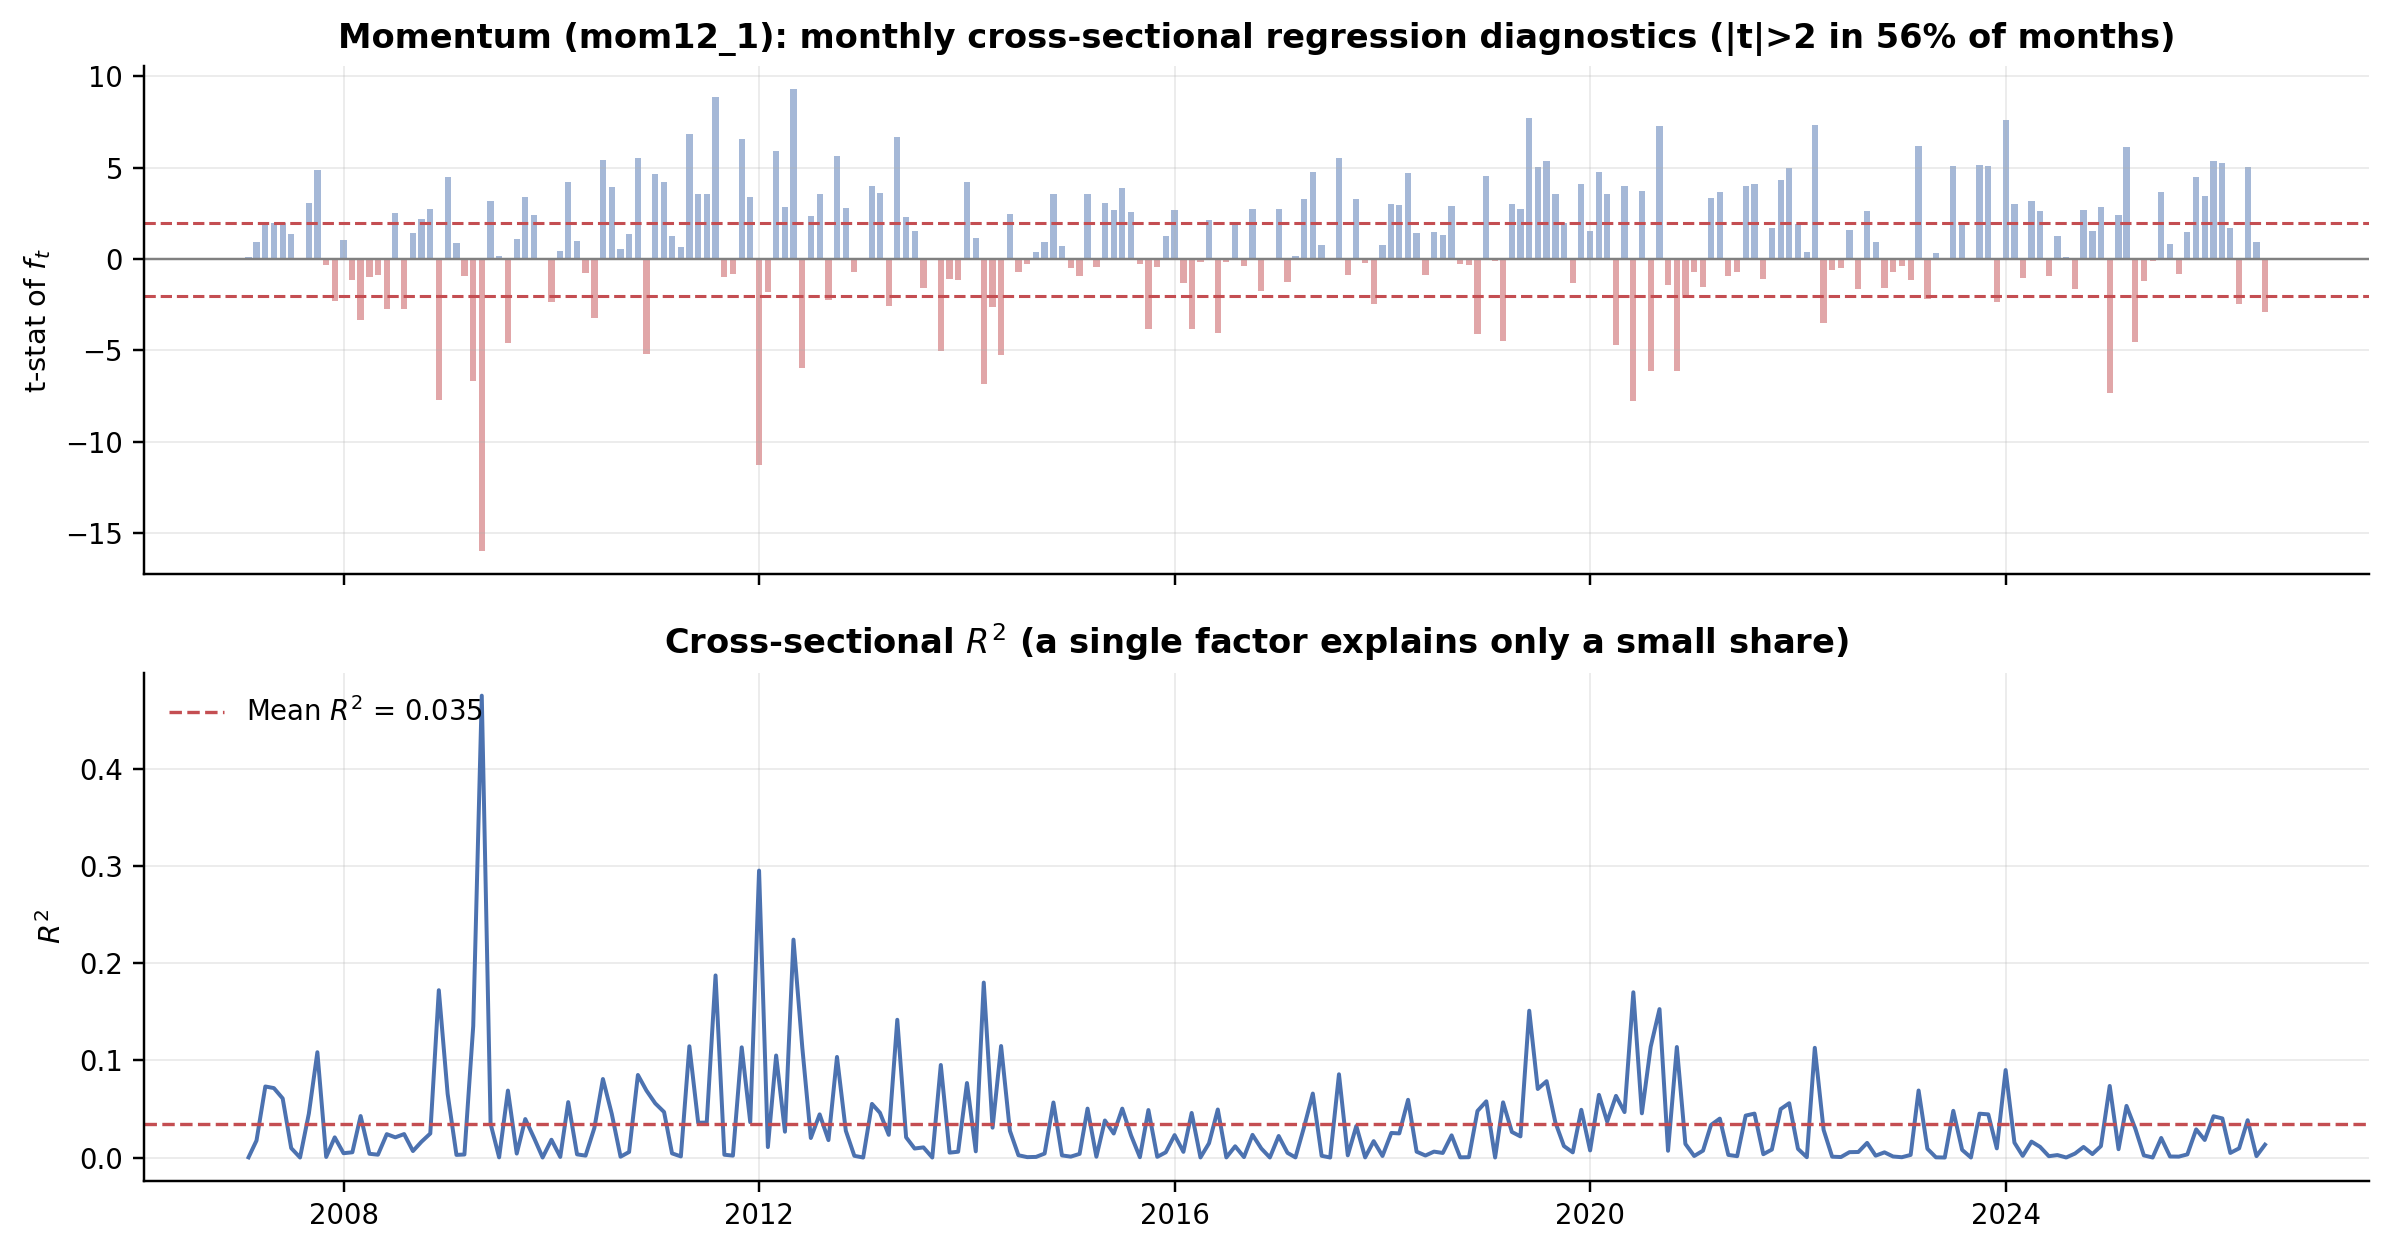

In [6]:
fig = fl.plotting.plot_factor_return_diagnostics(fr, factor=FACTOR_LABEL)
fl.plotting.savefig(fig, "04_factor_return/31_factor_return_diagnostics");

### IC との対応関係の確認

$f_t \approx \mathrm{IC}^{\text{Pearson}}_t \times \sigma_t(r)$ を数値で確認する。

In [7]:
ic_p = fl.ic.information_coefficient(panel, score_cols["none"], "fwd_rtn", method="pearson")
sd_r = panel.groupby(level="yyyymm")["fwd_rtn"].std()
approx = (ic_p * sd_r).reindex(fr.index)

print(f"corr(f_t, IC_t * sd(r_t)) = {fr['f'].corr(approx):.6f}")
print(f"平均 f = {fr['f'].mean() * 100:.3f} %/月,  平均 IC*sd = {approx.mean() * 100:.3f} %/月")

corr(f_t, IC_t * sd(r_t)) = 0.999745
平均 f = 0.377 %/月,  平均 IC*sd = 0.379 %/月


## 2. 中立化バリアント別（等ウェイト OLS）

Step 3 と同じ 4 バリアントで $f_t$ を出す。

In [8]:
frs_variant = {v: fl.regression.factor_return(panel, col, weighting="ew")
               for v, col in score_cols.items()}

pd.DataFrame({LABELS[v]: fl.regression.factor_return_summary(frs_variant[v]) for v in VARIANTS}).T[
    ["mean_monthly", "ann_return", "ann_vol", "IR", "t_stat_NW", "fm_t_stat", "hit_ratio",
     "frac_|t|>2", "mean_r2", "max_drawdown"]
]

,mean_monthly,ann_return,ann_vol,IR,t_stat_NW,fm_t_stat,hit_ratio,frac_|t|>2,mean_r2,max_drawdown
No neutralization,0.0038,0.0421,0.0863,0.4878,2.1848,2.3134,0.6026,0.5556,0.0346,-0.3171
Size-neutral,0.0036,0.0407,0.0780,0.5222,2.2941,2.4420,0.6282,0.5256,0.0305,-0.2898
Sector-neutral,0.0037,0.0416,0.0765,0.5437,2.4562,2.5325,0.6368,0.5171,0.0273,-0.2838
Size + sector neutral,0.0035,0.0401,0.0685,0.5857,2.6007,2.6959,0.6282,0.4744,0.0237,-0.2493


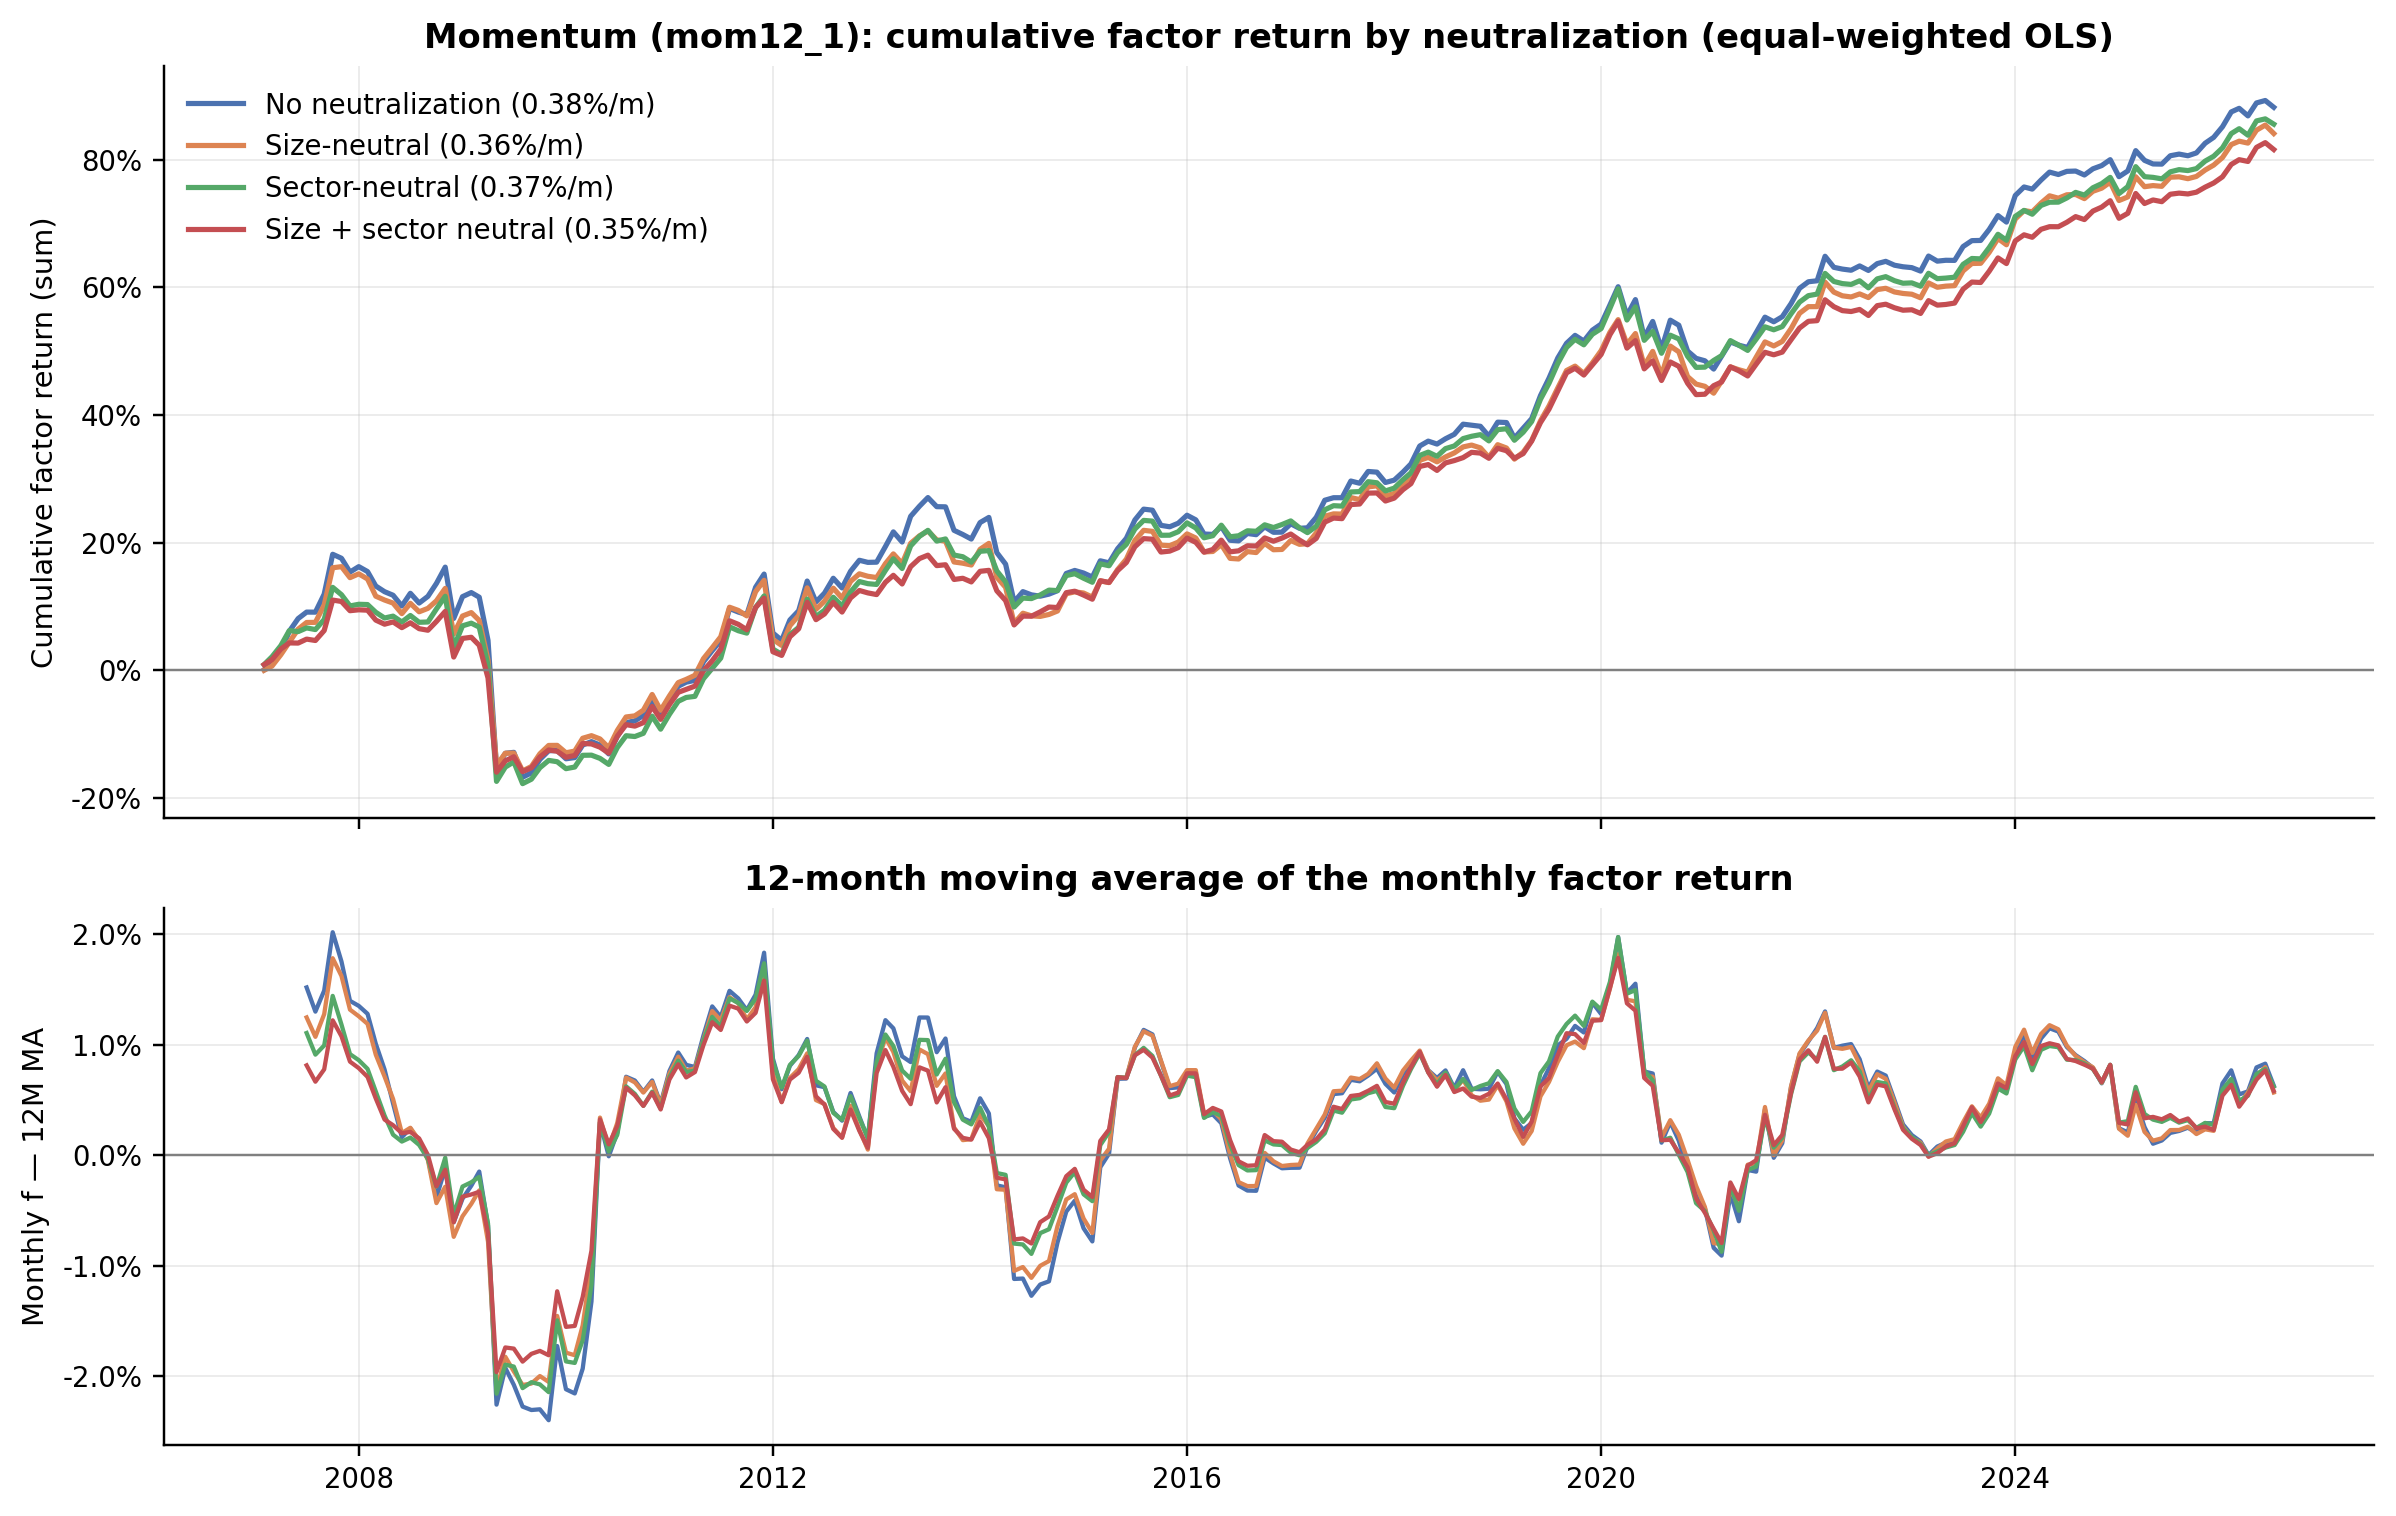

In [9]:
fig = fl.plotting.plot_factor_return_compare(frs_variant, factor=FACTOR_LABEL, labels=LABELS,
                                             title_suffix=" by neutralization (equal-weighted OLS)")
fl.plotting.savefig(fig, "04_factor_return/32_factor_return_by_neutralization");

## 3. 回帰ウェイト別

中立化は `size_sector`（Step 3 で最も良かった版）に固定し、回帰ウェイトを振る。

In [10]:
frs_weight = {w: fl.regression.factor_return(panel, score_cols["size_sector"], weighting=w)
              for w in WEIGHTINGS}

pd.DataFrame({WLABELS[w]: fl.regression.factor_return_summary(frs_weight[w]) for w in WEIGHTINGS}).T[
    ["mean_monthly", "ann_return", "ann_vol", "IR", "t_stat_NW", "fm_t_stat", "hit_ratio", "mean_r2"]
]

,mean_monthly,ann_return,ann_vol,IR,t_stat_NW,fm_t_stat,hit_ratio,mean_r2
Equal-weighted OLS,0.0035,0.0401,0.0685,0.5857,2.6007,2.6959,0.6282,0.0237
sqrt(Cap)-weighted WLS,0.0027,0.0304,0.0755,0.4028,1.9466,1.9236,0.5983,0.0259
Cap-weighted WLS,0.0021,0.0213,0.0892,0.2386,1.2340,1.2427,0.5855,0.0360


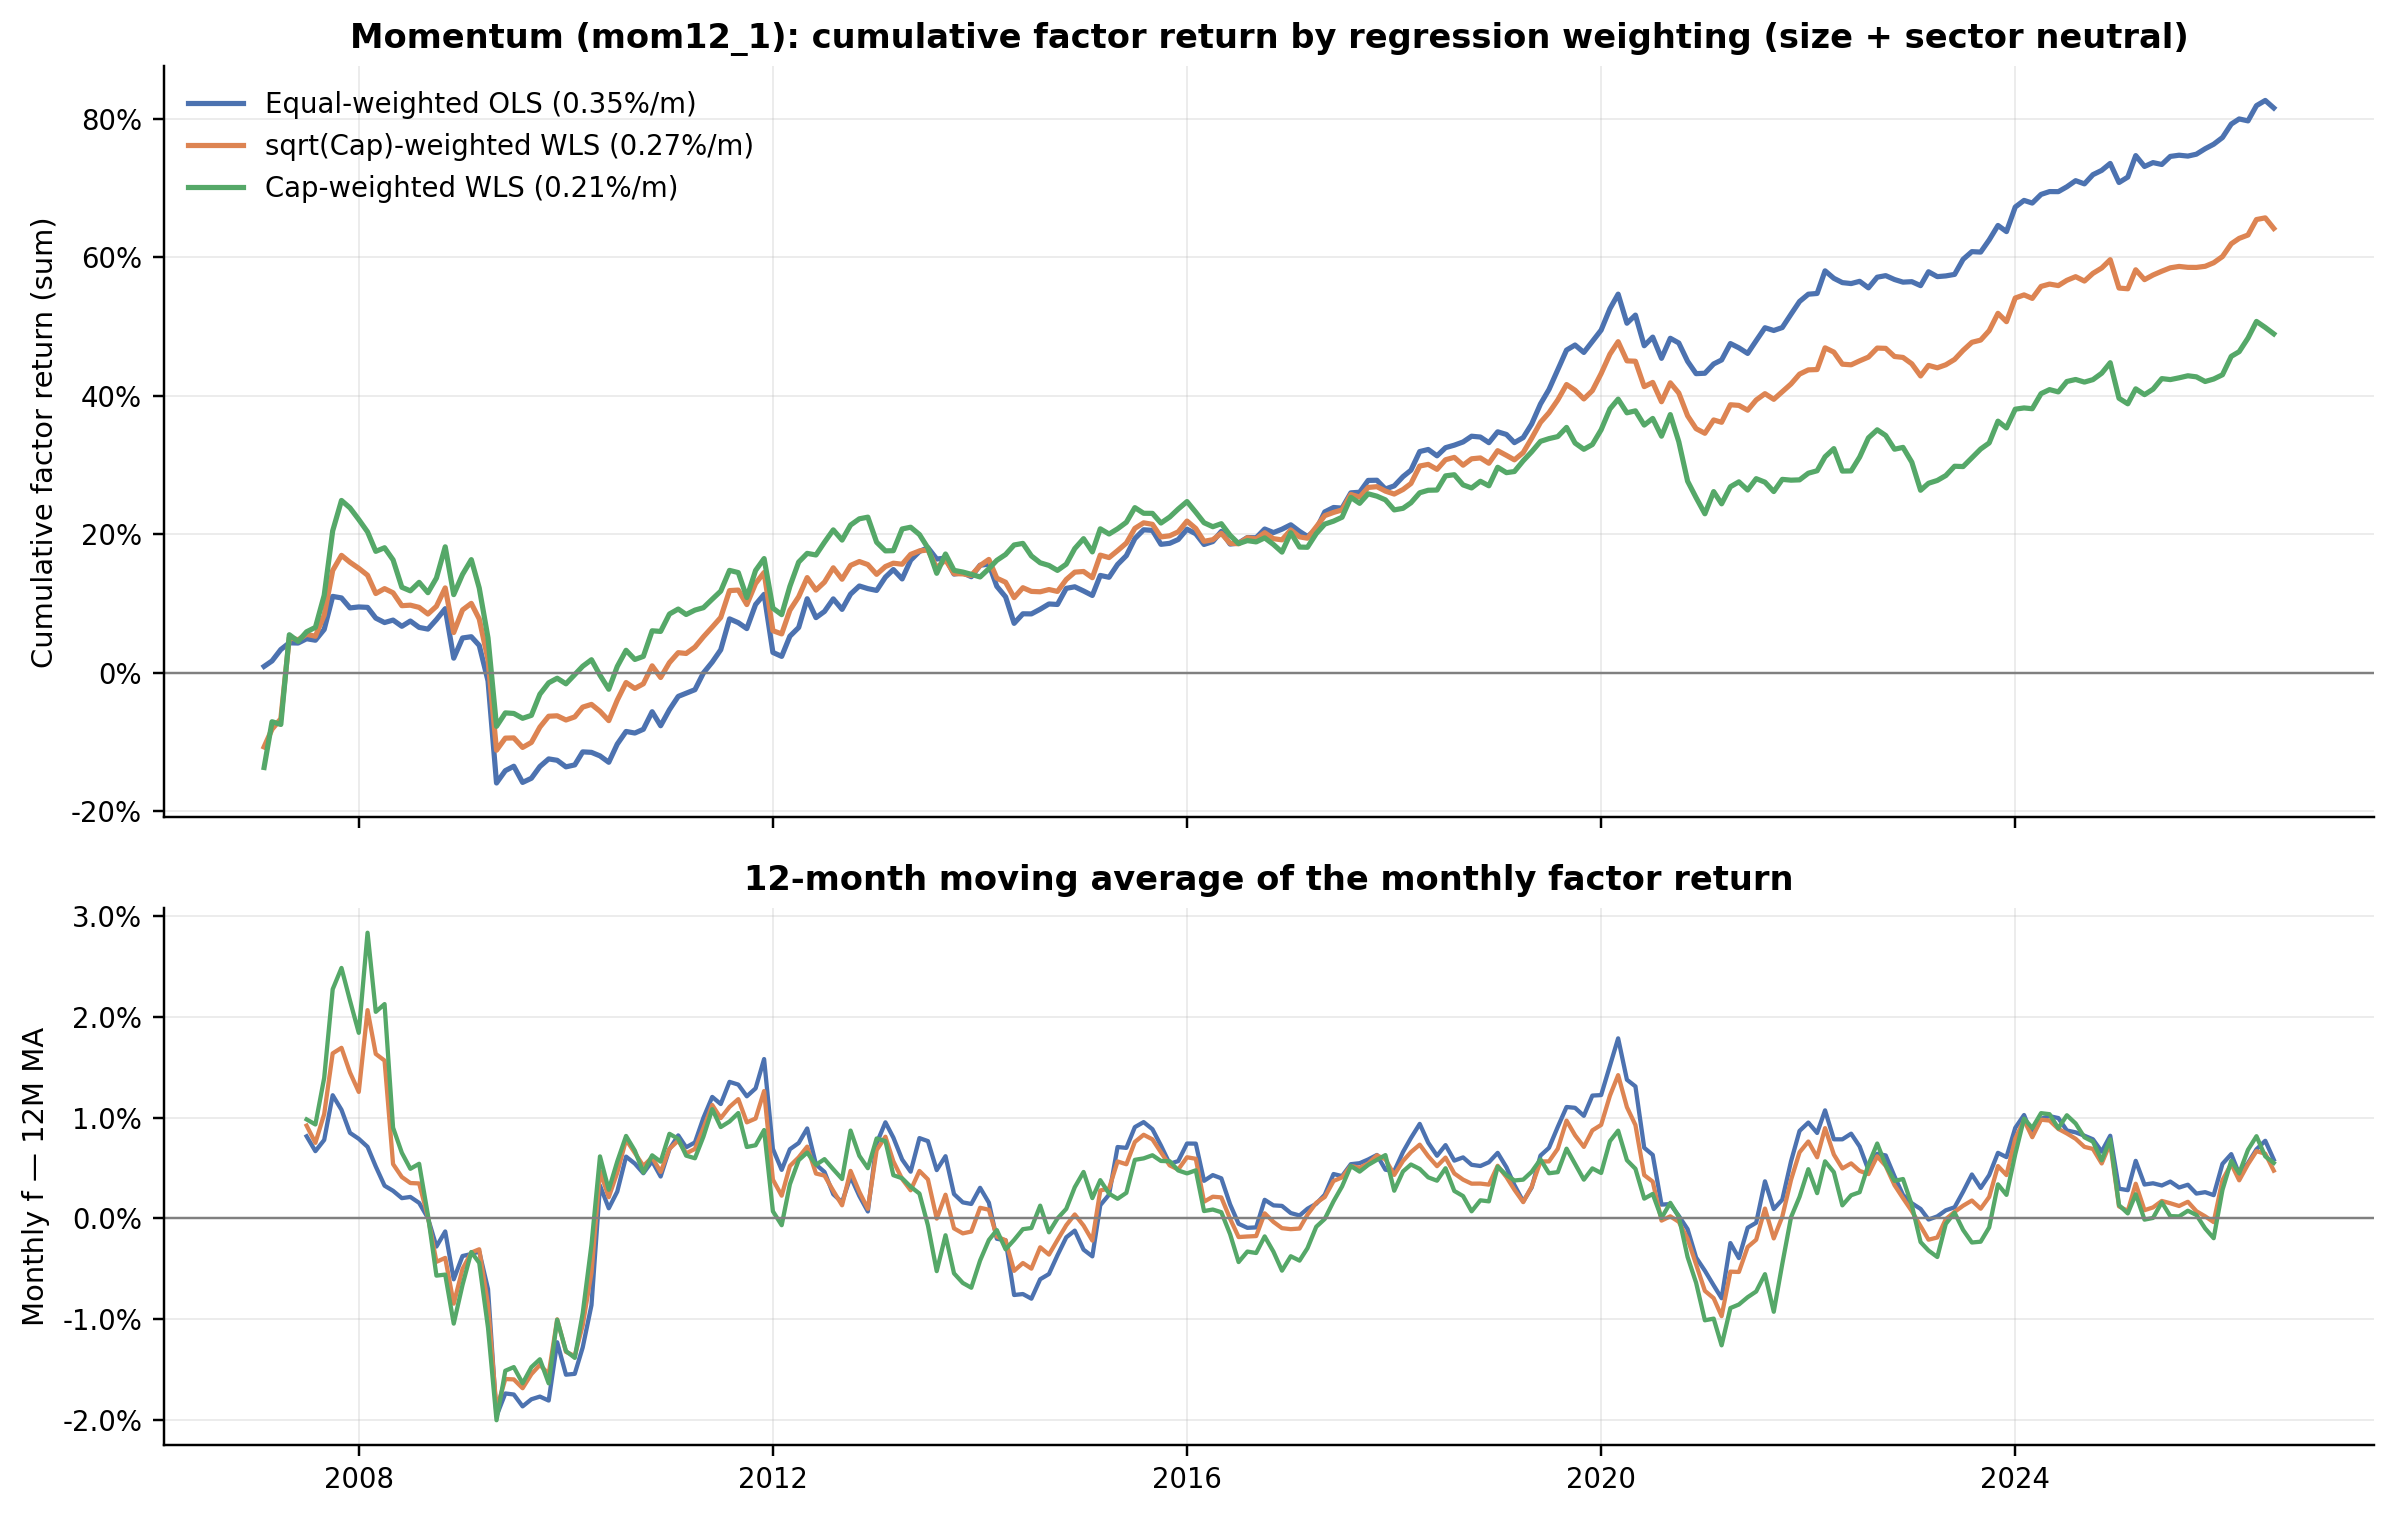

In [11]:
fig = fl.plotting.plot_factor_return_compare(frs_weight, factor=FACTOR_LABEL, labels=WLABELS,
                                             title_suffix=" by regression weighting (size + sector neutral)")
fl.plotting.savefig(fig, "04_factor_return/33_factor_return_by_weighting");

## 4. $f_t$ のシャープレシオ・ドローダウンは意味があるか

$f_t$ は「$x$ に単位エクスポージャーを持つゼロ投資ポートフォリオ」のリターンなので、
比率・分布の統計を取ること自体は定義上正しい。ただし**読める部分と読めない部分がある**。

**読める（比較・診断として有効）**

- **IR = $\bar f / \sigma_f$** — 無リスク資産を引く必要がない（既にゼロ投資）ので、
  そのままシャープレシオに相当する。ICIR とほぼ同じ情報だが、リターンの単位を持つぶん解釈しやすい。
  ファクター間・中立化バリアント間の比較には最も使いやすい指標
- **歪度・最悪月・DDの形状** — IC では見えない。IC は無次元で分布の非対称性を潰してしまうが、
  $f_t$ なら「モメンタム・クラッシュ」のような**左裾リスク**が可視化される。
  ファクター選択で「平均は同じだが片方は年に一度殴られる」を区別できる

**読めない（実装 P&L の予測として使えない）**

- 回帰が含意するポートフォリオは**ウェイトが青天井**（ロングオンリー制約も上限もない）。
  極端なエクスポージャーの銘柄に大きなウェイトが乗り得る
- **売買コスト・ショートコスト・キャパシティがゼロ**の前提
- 「1標準偏差あたり」で正規化しているため、**グロスエクスポージャーが月ごとに変動**する。
  一定の資金量を運用した場合の損益ではない

したがって **DD の水準は損益予測ではなく、リスクの形状を見る道具**として使う。
実装に近い水準が知りたい場合は、分位ロングショート（Q5-Q1）の DD を見るべき。
以下で両者を並べる。

In [12]:
# 同じスコアで「回帰の f_t」と「分位ロングショート Q5-Q1」を並べる
score = score_cols["size_sector"]
res_ls = fl.quantile.quantile_returns(panel, score, q=5, ascending=True)

f_ew = frs_weight["ew"]["f"]
ls_ew = res_ls["ew"]["Q5-Q1"]
ls_cw = res_ls["cw"]["Q5-Q1"]

pd.DataFrame({
    "Regression $f_t$ (EW OLS)": fl.metrics.summarize(f_ew),
    "Quintile L/S Q5-Q1 (EW)": fl.metrics.summarize(ls_ew),
    "Quintile L/S Q5-Q1 (CW)": fl.metrics.summarize(ls_cw),
}).T[["ann_return", "ann_vol", "IR", "t_stat_NW", "hit_ratio", "skew", "worst_month", "max_drawdown"]]

,ann_return,ann_vol,IR,t_stat_NW,hit_ratio,skew,worst_month,max_drawdown
Regression $f_t$ (EW OLS),0.0401,0.0685,0.5857,2.6007,0.6282,-2.5967,-0.1475,-0.2493
Quintile L/S Q5-Q1 (EW),0.0917,0.1958,0.4680,2.4045,0.6154,-2.3455,-0.4092,-0.5891
Quintile L/S Q5-Q1 (CW),0.0426,0.2250,0.1892,1.2108,0.5556,-0.8140,-0.3812,-0.6404


In [13]:
# 回転率は分位ポートでしか定義できない（回帰の f_t には実装ウェイトが無い）
res_ls["ew_turnover"][["Q1", "Q5", "Q5-Q1"]].mean().mul(12).to_frame("annualized 1-way turnover").T

,Q1,Q5,Q5-Q1
annualized 1-way turnover,3.4832,3.2452,6.7284


## 5. B/P でも同じ分析

In [14]:
def run_factor_return(factor: str, method: str = METHOD, variants=VARIANTS,
                      weighting: str = "ew", start: int = START, end: int = END):
    # ファクター名だけで 中立化バリアント別のファクターリターンを一括実行
    p = fl.data.build_panel([factor], start=start, end=end)
    p, cols = fl.preprocess.make_neutral_variants(p, factor, method=method, variants=variants)
    return {v: fl.regression.factor_return(p, col, weighting=weighting) for v, col in cols.items()}


frs_bp = run_factor_return("bp_act")
pd.DataFrame({LABELS[v]: fl.regression.factor_return_summary(frs_bp[v]) for v in VARIANTS}).T[
    ["mean_monthly", "ann_return", "ann_vol", "IR", "t_stat_NW", "fm_t_stat", "hit_ratio", "mean_r2"]
]

,mean_monthly,ann_return,ann_vol,IR,t_stat_NW,fm_t_stat,hit_ratio,mean_r2
No neutralization,0.0007,0.0058,0.0743,0.0775,0.4849,0.5009,0.4786,0.0288
Size-neutral,0.0008,0.0074,0.0661,0.1118,0.6225,0.6353,0.4744,0.0248
Sector-neutral,0.0001,-0.0003,0.0644,-0.0046,0.1089,0.1189,0.4615,0.0220
Size + sector neutral,0.0003,0.0019,0.0558,0.0346,0.2499,0.2739,0.4786,0.0179


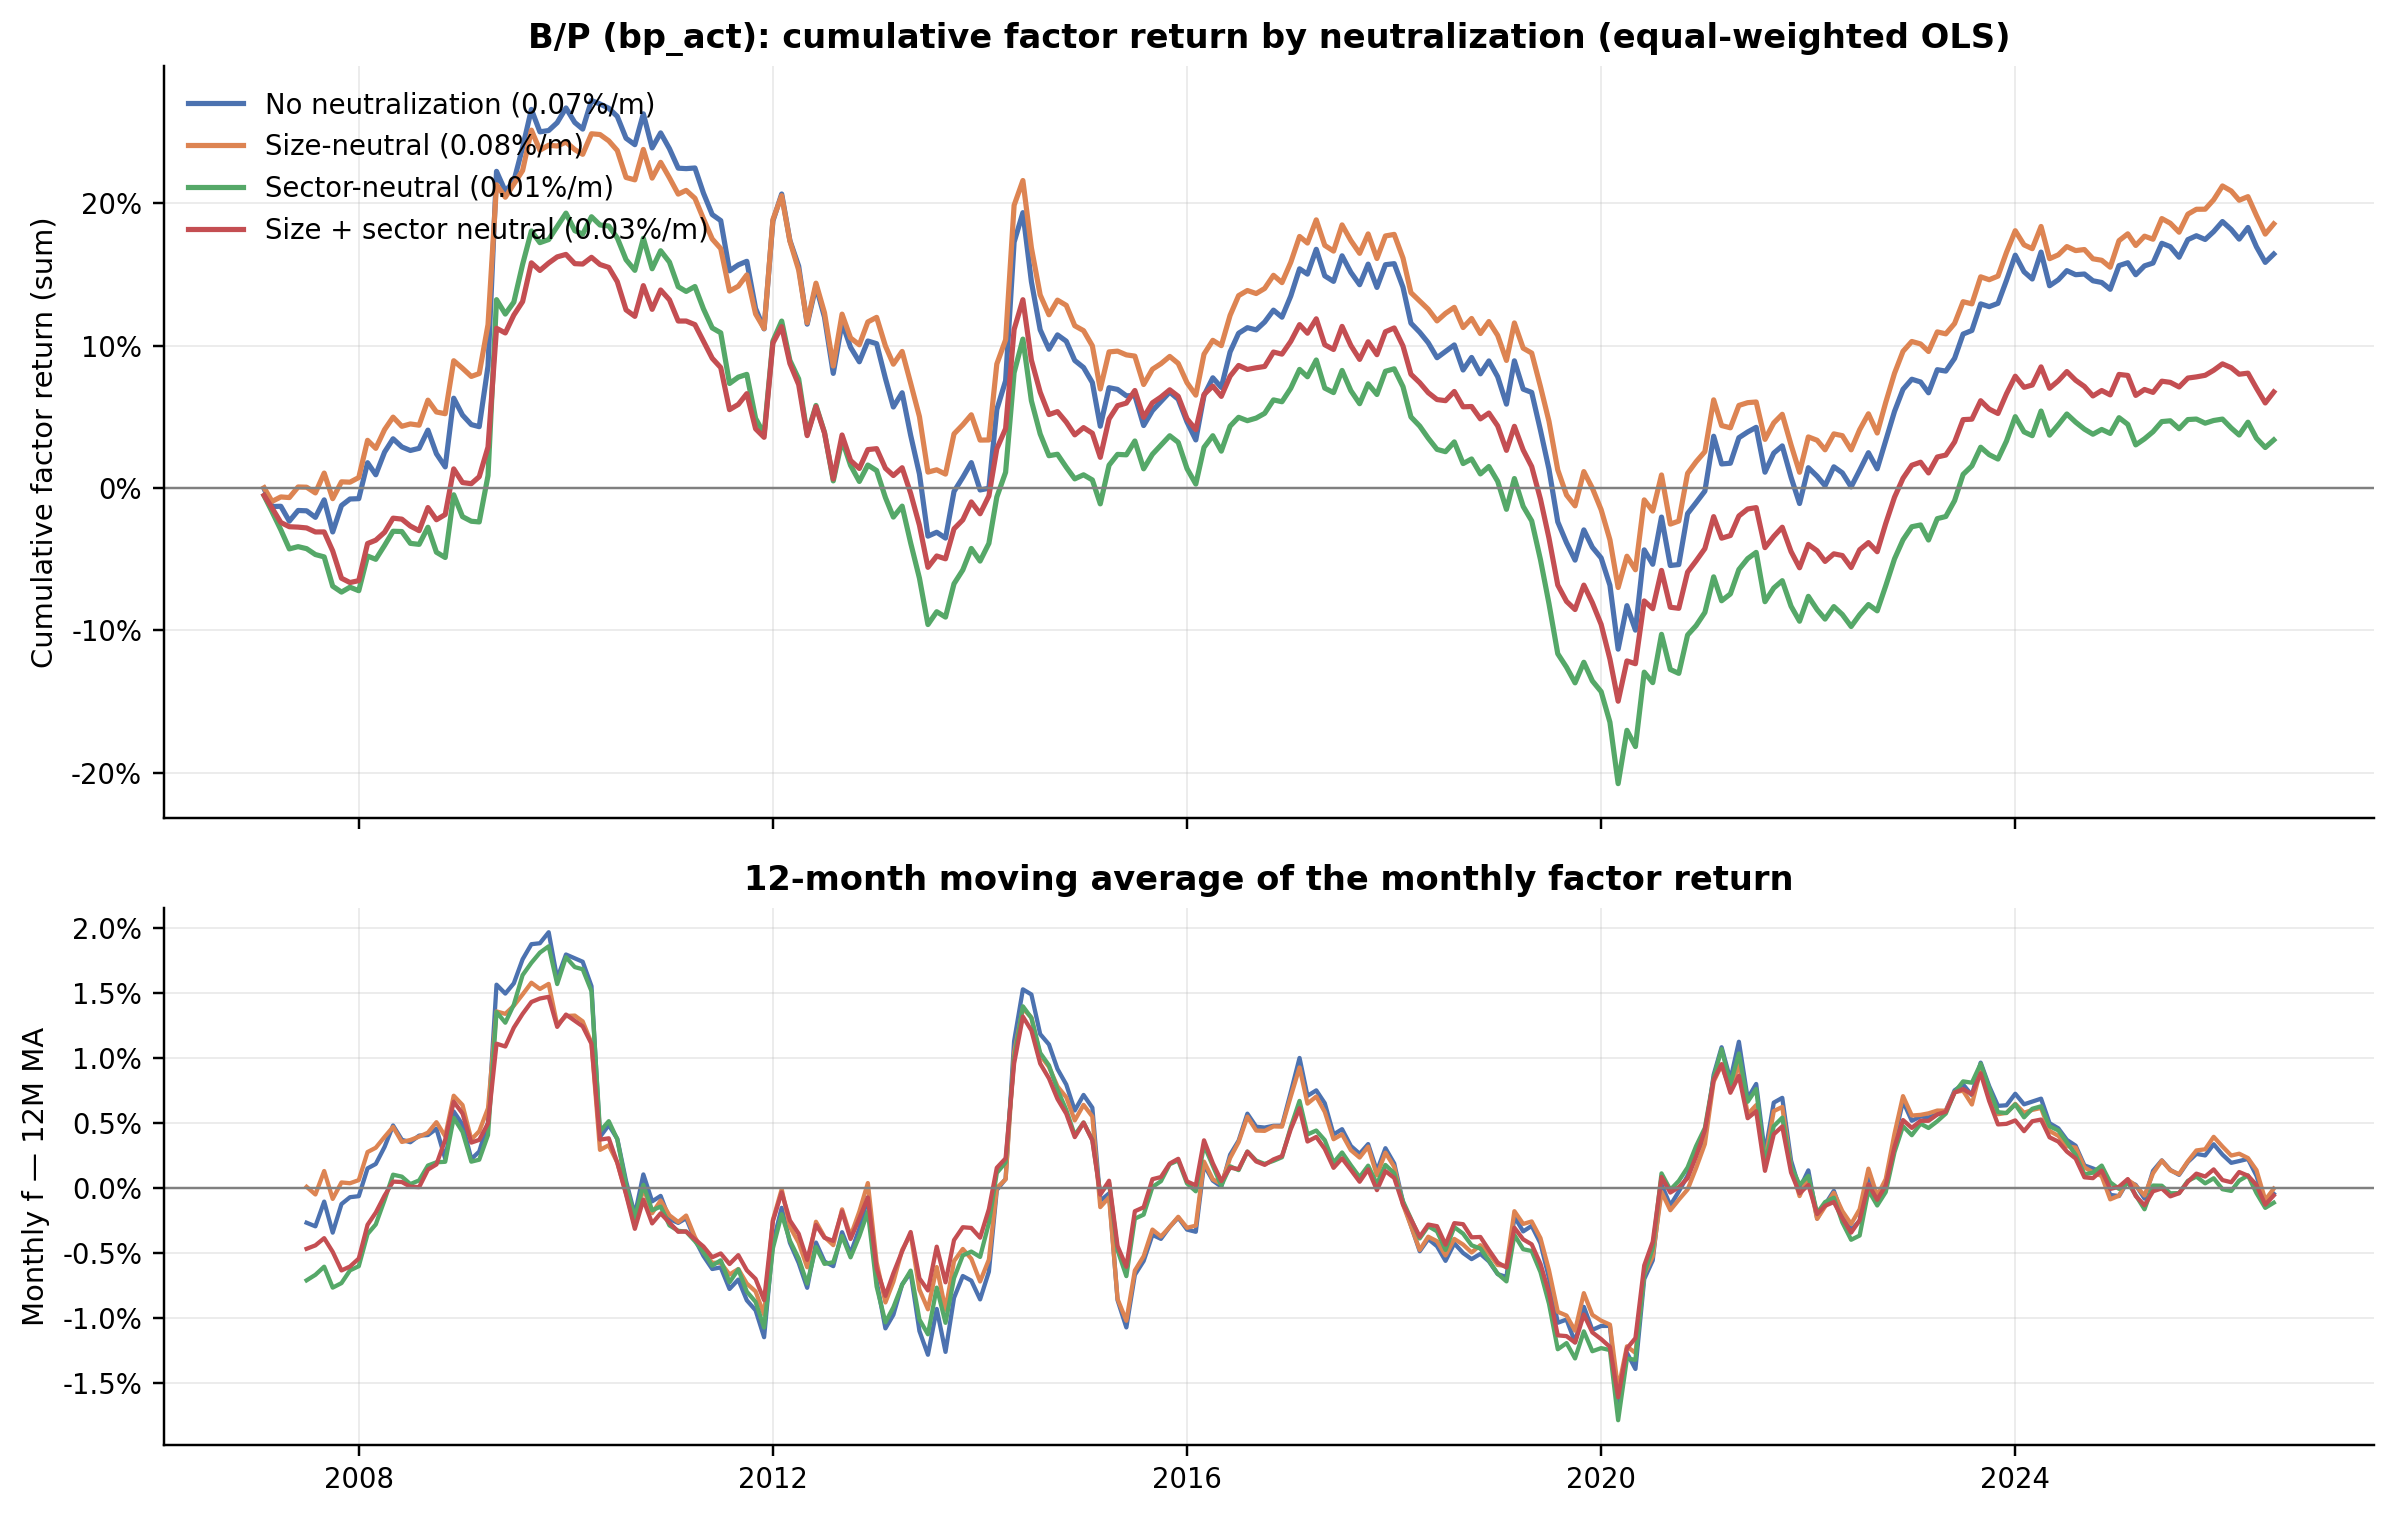

In [15]:
fig = fl.plotting.plot_factor_return_compare(frs_bp, factor="B/P (bp_act)", labels=LABELS,
                                             title_suffix=" by neutralization (equal-weighted OLS)")
fl.plotting.savefig(fig, "04_factor_return/34_factor_return_bp");

---

## まとめ — 3つの見方の対応

| | 使う情報 | 単位 | 実装との距離 |
|---|---|---|---|
| 分位分析 | 順序のみ | リターン（%） | 近い（そのままポートフォリオ） |
| IC | 順序 or 値 | 無次元 | 遠い（大きさが分からない） |
| ファクターリターン $f_t$ | 値（距離） | リターン（%） | 中間（理想化されたLS） |

3つが同じ符号・同じレジームを示すなら、その効果は前処理やウェイト規約に依存しない
頑健なものと判断できる。食い違う場合は、どこで食い違うかが診断になる:

- 分位 ○ / IC × → 効果が特定分位に集中（非単調・裾のみ）
- IC ○ / 分位 × → 効果は広く薄く、分位に束ねると消える
- EW ○ / CW × → 小型株に偏った効果